# **Лабораторная работа №1.**

## Задание

Найти полосы движения на изображении с дорогой ```./road1.png``` и получить точку схода этих прямых.

##### Выполнил: Викулов Максим

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

Загрузка изображения, отрисовка и получение его размеров

In [2]:
def show_image(img):
    cmap='gray' if len(img.shape) == 2 else 'viridis'
    plt.figure(figsize=(12, 12))
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

Image Shape: (590, 1178, 3)


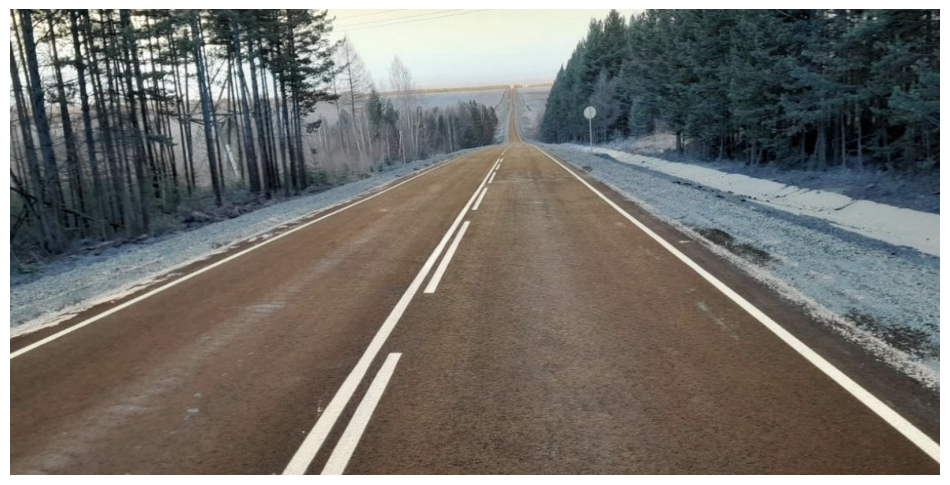

In [3]:
image = cv2.imread('road1.png')
print(f"Image Shape: {image.shape}")
show_image(image)

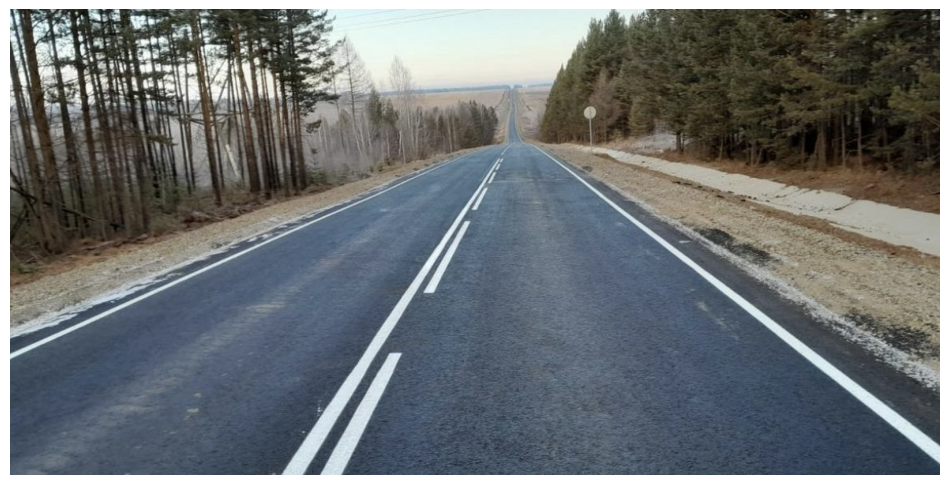

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR -> RGB
show_image(image_rgb)

Конвертируем в формат оттенков серого, добавляем размытие и увеличиваем контраст.

In [5]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY) # RGB -> Gray Scale
print(f"Shape for gray color image: {gray.shape}")

Shape for gray color image: (590, 1178)


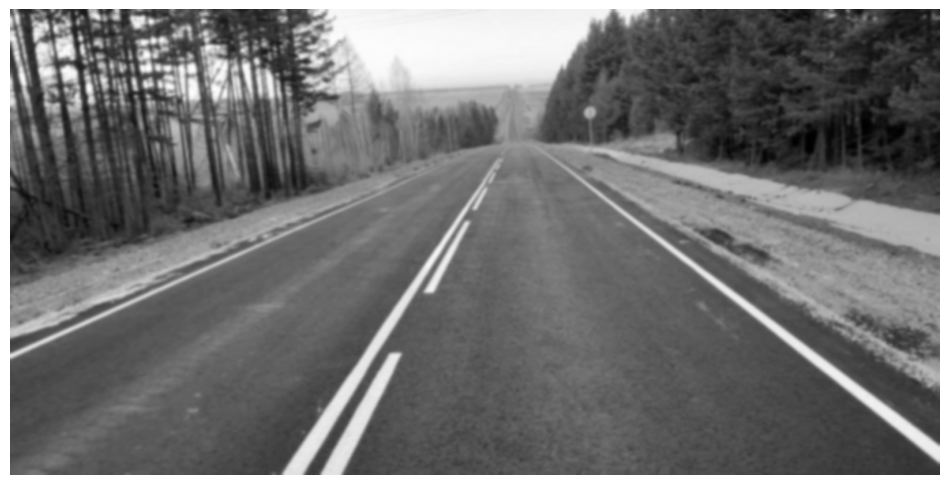

In [6]:
blur = cv2.GaussianBlur(gray, (9, 9), 0)
show_image(blur)

Находим края на полученном изображении

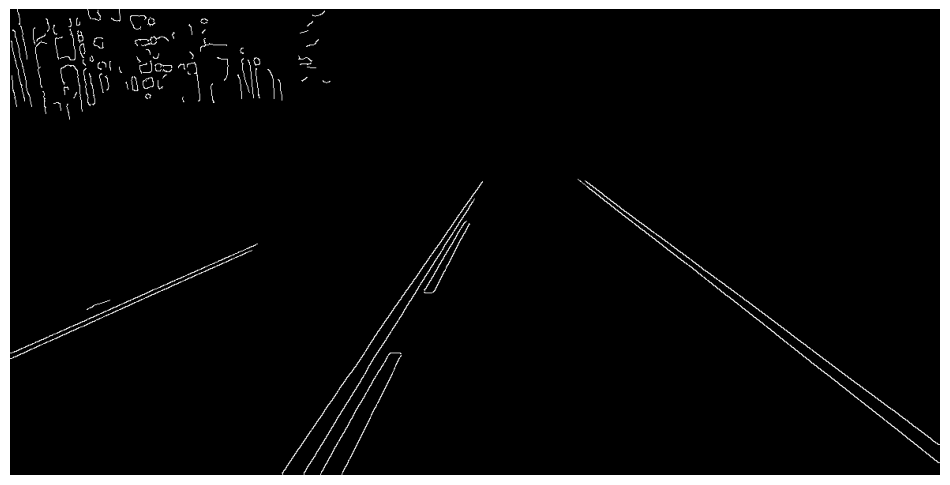

In [7]:
edges_gray_blur = cv2.Canny(blur, 200, 300)
show_image(edges_gray_blur)

Далее применяется преобразования Хафа - ```cv2.HoughLinesP```. Параметры подобраны так, чтобы явно выделить три полосы на дороге.

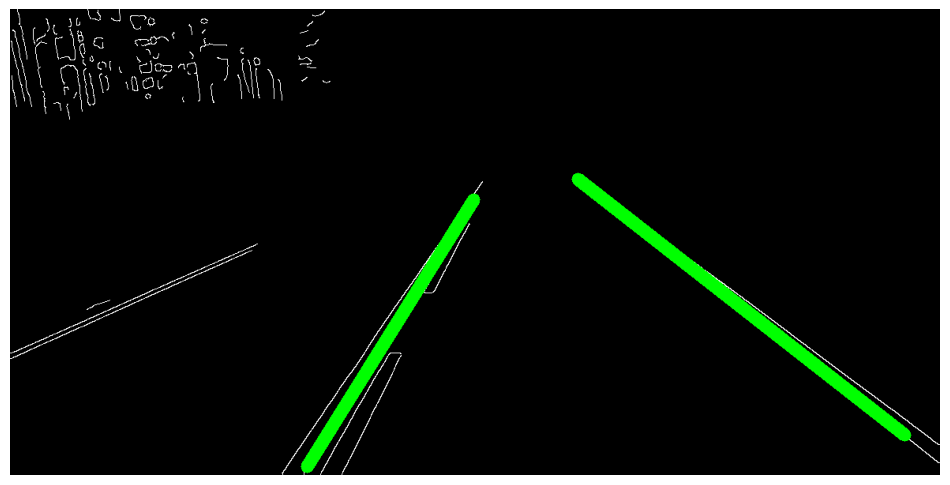

In [19]:
lines = cv2.HoughLinesP(image=edges_gray_blur,
                        rho=1,
                        theta=np.pi / 180,
                        threshold=250, 
                        minLineLength=320, 
                        maxLineGap=150 
)   

if lines is not None:
    color_img = cv2.cvtColor(edges_gray_blur, cv2.COLOR_GRAY2BGR)
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(color_img, (x1, y1), (x2, y2), (0, 255, 0), thickness=15)
    
    color_img_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
    show_image(color_img_rgb)

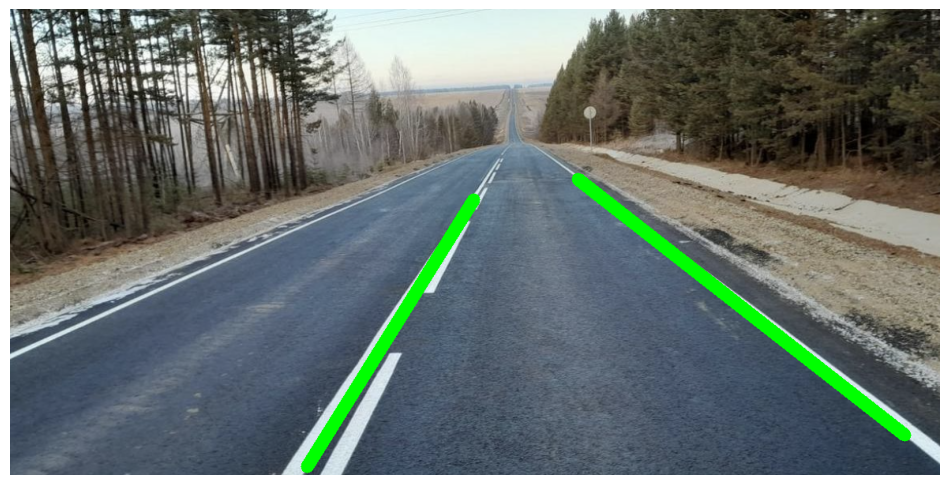

In [20]:
if lines is not None:
    img_with_lines = image_rgb.copy()
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 255, 0), 15)
    
    show_image(img_with_lines)

Найдем точку пересечения прямых и отобразим ее на оригинальном изображении

In [21]:
a, b = np.squeeze(lines[0]), np.squeeze(lines[1])

In [22]:
print(f"a = {a}")
print(f'b = {b}')

a = [ 719  215 1133  539]
b = [376 579 587 241]


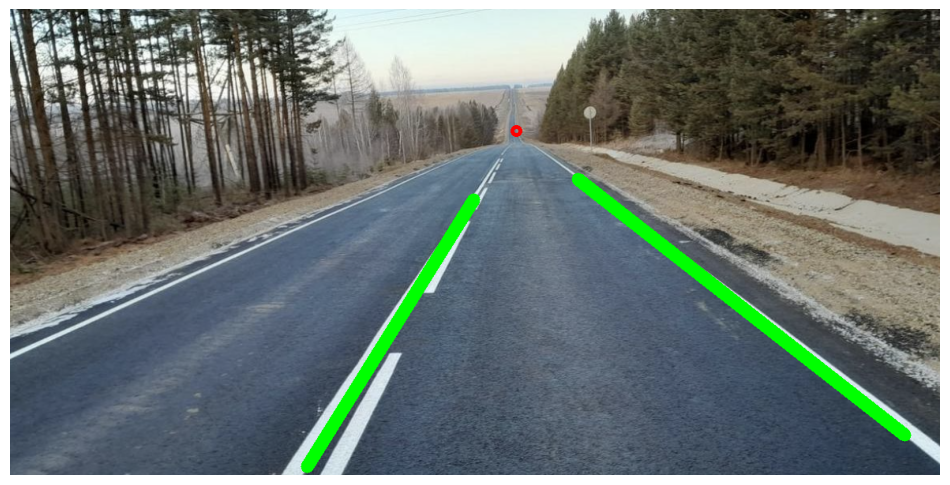

In [23]:
x1, y1, x2, y2 = a
x3, y3, x4, y4 = b
det = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
if det != 0:
    x_hat = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / det
    y_hat = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / det
    intersection_point = (int(x_hat), int(y_hat))
    cv2.circle(img_with_lines, intersection_point, 5, (255, 0, 0), 3)
    show_image(img_with_lines)